In [1]:
using Random
using PyPlot
using Statistics
using OrdinaryDiffEq
using LinearAlgebra

using Profile
using ProfileView

include("SuperradiantLasing/SuperradiantLasing.jl")
using .SuperradiantLasing

for n in names(SuperradiantLasing, all=true)
    @eval import .SuperradiantLasing: $(n)
end



In [ ]:
N = 10000
n_grid = 1500
N_traj = 100
τ_max = 40.0
t_ss = 3.0
r = 0.5 * N

#or t_max in [3.0]
    pop_model = PopulationModel(N, N ÷ 2, 1.0, 0.0, 0.0, r, 0.0)

    @profile τ_grid2, Cτ2, S_samples2, M_samples2 = simulate_correlator_ergodic(pop_model;
        N_traj = N_traj,
        t_ss = t_ss,
        τ_max = τ_max,
        n_grid = n_grid,
        S0 = pop_model.Jmax,
        M0 = -pop_model.Jmax,
        rng = Xoshiro(12345),
    )

    ω_grid, Sω2 = spectrum_even_fft(τ_grid2, Cτ2)
    scatter(ω_grid, Sω2 ./ maximum(Sω2))
    println("r=$r, FWH=$(spectrum_fwhm(ω_grid, Sω2))")
    xlabel(L"\omega-\omega_0")
    ylabel(L"S(\omega)")
    title("Spectrum")
#end

legend()
xlim(left = -15.0, right = 15.0)

LoadError: InterruptException:

: 

In [ ]:
N = 2000
n_grid = 1500
τ_max = 20.0
t_ss = 20.0
r = 0.7 * N
pop_model = PopulationModel(N, N ÷ 2, 1.0, 0.0, 0.0, r, 0.0)

Ss, Ms = get_stationary_population_samples_ergodic(pop_model, 70000;
    t_ss = 20.0,
    t_sample = 60.0,
    S0 = pop_model.Jmax,
    M0 = - pop_model.Jmax,
    rng = Xoshiro(1234),
)

xs1, c1 = integer_hist(Ss)
p1 = c1 ./ sum(c1)

xm1, cm1 = integer_hist(Ms)
pm1 = cm1 ./ sum(cm1)

plot_integer_step(xs1, p1, label = "S")
figure()
plot_integer_step(xm1, pm1, label = "MM")

function joint_hist_SM(Ss::Vector{Int}, Ms::Vector{Int}, N::Int)
    @assert length(Ss) == length(Ms)

    Jmax = N ÷ 2
    Mmax = Jmax

    counts = zeros(Int, Jmax + 1, 2Mmax + 1)

    @inbounds for i in eachindex(Ss)
        s = Ss[i]
        m = Ms[i]
        counts[s + 1, m + Mmax + 1] += 1
    end

    # initialize with NaN everywhere
    P = fill(NaN, Jmax + 1, 2Mmax + 1)

    # fill only physical region |M| ≤ S
    for s in 0:Jmax
        for m in -s:s
            P[s + 1, m + Mmax + 1] = counts[s + 1, m + Mmax + 1]
        end
    end

    P ./= sum(counts)

    Svals = collect(0:Jmax)
    Mvals = collect(-Mmax:Mmax)

    return Svals, Mvals, P
end

Svals, Mvals, P = joint_hist_SM(Ss, Ms, N)

figure()
imshow(
    P',
    extent = (Svals[1], Svals[end], Mvals[1], Mvals[end]),
    origin = "lower",
    aspect = "auto",
)
colorbar(label = "P(S,M)")
xlabel("S")
ylabel("M")
title("Joint distribution in physical state space")

plot(Svals, Svals, "w--", linewidth=1)
plot(Svals, -Svals, "w--", linewidth=1)

LoadError: UndefVarError: `integer_hist` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

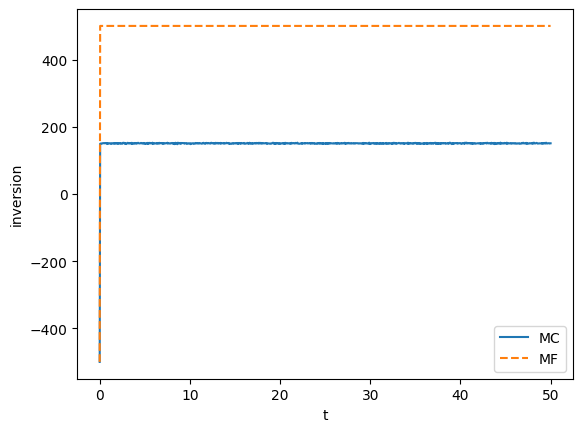

Matched parameters:
  thresholds γp⁻, γp⁺ = (0.0, 1000.0)
  lasing regime? true
0.31622776601683794
Matched parameters:
  thresholds γp⁻, γp⁺ = (0.0, 1000.0)
  lasing regime? true


LoadError: FieldError: type NamedTuple has no field `errors`, available fields: `t`, `mc_M`, `mf_sz`, `lasing`, `thresholds`, `params`

In [ ]:
N = 1000
mc_model = PopulationModel(
    N,
    N ÷ 2,
    1.0,
    0.0,
    0.0,
    0.3 * N,
    0.0,
)

out = compare_mc_to_meanfield(
    mc_model;
    N_traj = 1000,
    t_max = 50.0,
    n_grid = 1000,
    S0 = mc_model.Jmax,
    M0 = -mc_model.Jmax,
    g = 0.01,
    rng = Xoshiro(1234),
)

figure()
plot(out.t, out.mc_M, label = "MC")
plot(out.t, out.mf_sz, "--", label = "MF")
xlabel("t")
ylabel("inversion")
legend()

In [ ]:
using LinearAlgebra
using DifferentialEquations

# ----------------------------
# Parameters
# ----------------------------
Base.@kwdef struct BadCavityParams
    N::Int
    g::Float64          # single-atom cavity coupling (paper's Ω)
    kappa::Float64      # cavity linewidth (paper's κ)
    gamma::Float64      # spontaneous decay rate (paper's γ)
    w::Float64          # repump rate
    gamma_phi::Float64  # pure dephasing rate, replacing 1/T2
    Delta::Float64 = 0.0  # cavity-atom detuning Δ = ωc - ωa
end

# ----------------------------
# Mean-field / cumulant EOM
#
# State vector:
# u = [z, Re(p), Im(p), c, n]
#
# z = <σ^z>
# p = <a† σ^->
# c = <σ1^+ σ2^->
# n = <a† a>
#
# Uses the paper's Eq. (2)-(5), with 1/T2 -> gamma_phi,
# and neglects the third-order cumulant in Eq. (3),
# exactly as stated there.
# ----------------------------
function badcavity_rhs!(du, u, pars::BadCavityParams, t)
    z, px, py, c, n = u
    p = px + 1im * py

    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    d0 = (w - γ) / (w + γ)

    # Eq. (2)
    dz = -(w + γ) * (z - d0) + 1im * g * (p - conj(p))

    # Eq. (3), third-order cumulant dropped
    #dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
    #     1im * g/2 * (n * z + z/2 + (N - 1) * c)
    dp = -((w + γ)/2 + γϕ + κ/2 - 1im * Δ) * p +
     1im * g/2 * (n * z + (z + 1)/2 + (N - 1) * c)

    # Eq. (4)
    dc = -(w + γ + 2γϕ) * c + (g * z / (2im)) * (p - conj(p))

    # Eq. (5)
    dn = -κ * n + (N * g / (2im)) * (p - conj(p))

    du[1] = real(dz)
    du[2] = real(dp)
    du[3] = imag(dp)
    du[4] = real(dc)   # c stays real in the resonant case
    du[5] = real(dn)
    return nothing
end

# ----------------------------
# Integrate to steady state
# ----------------------------
function badcavity_steady_state(pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0,
        reltol = 1e-10,
        abstol = 1e-12)

    prob = ODEProblem(badcavity_rhs!, u0, (0.0, tmax), pars)
    sol = solve(prob, Rodas5P(); reltol=reltol, abstol=abstol)

    u = sol.u[end]
    z, px, py, c, n = u
    p = px + 1im * py

    return (
        z = z,
        p = p,
        c = c,
        n = n,
        sol = sol,
    )
end

# ----------------------------
# Regression matrix for the spectrum
#
# q(t) = [ G(t), H(t) ]^T
# G(t) = <a†(t) a(0)>
# H(t) = <σ^+(t) a(0)>
#
# Following the paper's Eq. (9), but with pure dephasing γϕ
# instead of 1/T2, so the transverse decay is:
# Γperp = (w + γ)/2 + γϕ
#
# On resonance, the spectrum is Lorentzian in the paper's closure.
# Here we evaluate it directly from the resolvent, which is more robust.
# ----------------------------
function regression_matrix(pars::BadCavityParams, z_ss)
    N  = pars.N
    g  = pars.g
    κ  = pars.kappa
    γ  = pars.gamma
    w  = pars.w
    γϕ = pars.gamma_phi
    Δ  = pars.Delta

    Γperp = (w + γ)/2 + γϕ

    # q̇ = A q
    A = ComplexF64[
        -κ/2                    1im * N * g / 2
        -1im * g * z_ss / 2    -(Γperp + 1im * Δ)
    ]
    return A
end

# ----------------------------
# Spectrum from the Laplace/resolvent formula
#
# S(ω) = 2 Re ∫_0^∞ dt e^{i ω t} <a†(t) a(0)>
#
# For q̇ = A q and q(0) = q0:
# ∫_0^∞ dt e^{iω t} q(t) = -(A + iω I)^(-1) q0
# ----------------------------
function badcavity_spectrum(ωgrid, pars::BadCavityParams, ss)
    z_ss = ss.z
    n_ss = ss.n
    p_ss = ss.p

    A = regression_matrix(pars, z_ss)

    # Initial conditions from the steady state
    # G(0) = <a† a> = n_ss
    # H(0) = <σ^+ a> = conj(<a† σ^->) = conj(p_ss)
    q0 = ComplexF64[n_ss, conj(p_ss)]

    S = similar(ωgrid, Float64)
    I2 = Matrix{ComplexF64}(I, 2, 2)

    for (j, ω) in pairs(ωgrid)
        val = ((1im * ω * I2 - A) \ q0)
        S[j] = 2 * real(val[1])
    end

    return S
end

# ----------------------------
# Convenience wrapper
# ----------------------------
function steady_state_and_spectrum(ωgrid, pars::BadCavityParams;
        u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
        tmax = 10_000.0)

    #@show pars.w / (pars.N * pars.g^2 / pars.kappa)

    ss = badcavity_steady_state(pars; u0=u0, tmax=tmax)
    Sω = badcavity_spectrum(ωgrid, pars, ss)
    return ss, Sω
end


steady_state_and_spectrum (generic function with 1 method)

In [ ]:

# ============================================
# Burn-in / quasi-stationary approximation
# ============================================

# Simulate exactly only up to t_mix.
# Returns:
#   contrib      : contribution on τ_grid for τ <= t_mix
#   survived     : whether trajectory is still alive at t_mix
#   amp_mix      : alive amplitude at t_mix, i.e. w_in * readout(state at t_mix)
#   sink_mix     : sink rate at t_mix
#   S_mix, M_mix : state at t_mix (mainly for diagnostics)
function simulate_coherence_sector_to_mix(
    model::CoherenceModel,
    S0::Int,
    M0::Int,
    τ_grid::AbstractVector,
    t_mix::Float64;
    rng::AbstractRNG = Random.default_rng(),
)
    st = CoherenceState(S0, M0, 0.0, false)
    buf = CoherenceEventBuffer()

    contrib = zeros(Float64, length(τ_grid))
    w_in = initial_coherence_weight(S0, M0)

    if !valid_coherence_state(S0, M0, model.Jmax)
        return contrib, false, 0.0, 0.0, S0, M0
    end

    idx = 1
    nτ = length(τ_grid)

    while idx <= nτ
        τ = τ_grid[idx]
        if τ > t_mix
            break
        end

        current_val = st.absorbed ? 0.0 : w_in * coherence_readout(st.S, st.M)

        ok = coherence_step!(rng, st, buf, model)

        if !ok
            @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
                contrib[idx] = current_val
                idx += 1
            end
            return contrib, false, 0.0, 0.0, st.S, st.M
        end

        @inbounds while idx <= nτ && τ_grid[idx] <= min(st.t, t_mix)
            contrib[idx] = current_val
            idx += 1
        end

        if st.absorbed
            @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
                contrib[idx] = 0.0
                idx += 1
            end
            return contrib, false, 0.0, 0.0, st.S, st.M
        end
    end

    # If no event reached t_mix yet, fill remaining early grid points with current value
    if !st.absorbed
        current_val = w_in * coherence_readout(st.S, st.M)
        @inbounds while idx <= nτ && τ_grid[idx] <= t_mix
            contrib[idx] = current_val
            idx += 1
        end

        build_coherence_events!(buf, model, st)
        sink_mix = buf.sink_rate
        amp_mix = current_val
        return contrib, true, amp_mix, sink_mix, st.S, st.M
    else
        return contrib, false, 0.0, 0.0, st.S, st.M
    end
end


# Build tail from a deterministic quasi-stationary exponential
@inline function add_deterministic_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
)
    if amp_mix == 0.0
        return nothing
    end

    @inbounds for i in eachindex(τ_grid)
        τ = τ_grid[i]
        if τ > t_mix
            Cτ[i] += amp_mix * exp(-λ_qs * (τ - t_mix))
        end
    end
    return nothing
end


# Build tail from one sampled exponential absorption time
@inline function add_sampled_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
    rng::AbstractRNG,
)
    if amp_mix == 0.0
        return nothing
    end

    if λ_qs <= 0.0
        @inbounds for i in eachindex(τ_grid)
            if τ_grid[i] > t_mix
                Cτ[i] += amp_mix
            end
        end
        return nothing
    end

    T_tail = -log(rand(rng)) / λ_qs
    t_abs = t_mix + T_tail

    @inbounds for i in eachindex(τ_grid)
        τ = τ_grid[i]
        if τ > t_mix && τ <= t_abs
            Cτ[i] += amp_mix
        end
    end

    return nothing
end


# Main approximation from initial samples.
#
# tail_mode = :deterministic  -> amp_mix * exp(-λ_qs (τ-t_mix))
# tail_mode = :sampled        -> amp_mix * 1_{τ < t_mix + Exp(λ_qs)}
#
# estimate_lambda = :mean_sink
#   λ_qs = average sink rate over survivors at t_mix
#
function simulate_coherence_correlator_from_samples_qs(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)
    @assert 0.0 <= t_mix <= τ_max

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    N = length(S_samples)
    survived = falses(N)
    amp_mix = zeros(Float64, N)
    sink_mix = zeros(Float64, N)
    S_mix = zeros(Int, N)
    M_mix = zeros(Int, N)

    # exact burn-in
    for n in eachindex(S_samples)
        contrib_n, survived_n, amp_n, sink_n, S_n, M_n = simulate_coherence_sector_to_mix(
            model,
            S_samples[n],
            M_samples[n],
            τ_grid,
            t_mix;
            rng = rng,
        )

        Cτ .+= contrib_n
        survived[n] = survived_n
        amp_mix[n] = amp_n
        sink_mix[n] = sink_n
        S_mix[n] = S_n
        M_mix[n] = M_n
    end

    n_surv = count(survived)

    λ_qs = n_surv == 0 ? 0.0 : sum(sink_mix[survived]) / n_surv

    # approximate tail
    if tail_mode == :deterministic
        for n in eachindex(S_samples)
            if survived[n]
                add_deterministic_qs_tail!(Cτ, τ_grid, t_mix, amp_mix[n], λ_qs)
            end
        end
    elseif tail_mode == :sampled
        for n in eachindex(S_samples)
            if survived[n]
                add_sampled_qs_tail!(Cτ, τ_grid, t_mix, amp_mix[n], λ_qs, rng)
            end
        end
    else
        error("Unknown tail_mode = $tail_mode. Use :deterministic or :sampled.")
    end

    Cτ ./= N

    stats = (
        λ_qs = λ_qs,
        n_survived = n_surv,
        survival_fraction = n_surv / N,
        mean_amp_mix = n_surv == 0 ? 0.0 : sum(amp_mix[survived]) / n_surv,
        mean_sink_mix = λ_qs,
        S_mix = S_mix,
        M_mix = M_mix,
        amp_mix = amp_mix,
        sink_mix = sink_mix,
        survived = survived,
    )

    return τ_grid, Cτ, stats
end


function simulate_correlator_qs(
    pop_model::PopulationModel;
    N_traj::Int,
    t_ss::Float64,
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    S0::Int = pop_model.Jmax,
    M0::Int = pop_model.Jmax,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    S_samples, M_samples = get_stationary_population_samples(
        pop_model,
        N_traj;
        t_ss = t_ss,
        S0 = S0,
        M0 = M0,
        rng = rng,
    )

    coh_model = CoherenceModel(pop_model)

    τ_grid, Cτ, stats = simulate_coherence_correlator_from_samples_qs(
        S_samples,
        M_samples,
        coh_model;
        τ_max = τ_max,
        t_mix = t_mix,
        n_grid = n_grid,
        tail_mode = tail_mode,
        rng = rng,
    )

    return τ_grid, Cτ, S_samples, M_samples, stats
end


function simulate_correlator_ergodic_qs(
    pop_model::PopulationModel;
    N_traj::Int,
    t_ss::Float64,
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    S0::Int = pop_model.Jmax,
    M0::Int = pop_model.Jmax,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    S_samples, M_samples = get_stationary_population_samples_ergodic(
        pop_model,
        N_traj;
        t_ss = t_ss,
        t_sample = t_ss * 3,
        S0 = S0,
        M0 = M0,
        rng = rng,
    )

    coh_model = CoherenceModel(pop_model)

    τ_grid, Cτ, stats = simulate_coherence_correlator_from_samples_qs(
        S_samples,
        M_samples,
        coh_model;
        τ_max = τ_max,
        t_mix = t_mix,
        n_grid = n_grid,
        tail_mode = tail_mode,
        rng = rng,
    )

    return τ_grid, Cτ, S_samples, M_samples, stats
end

simulate_correlator_ergodic_qs (generic function with 1 method)

In [ ]:
# ============================================
# Burn-in / quasi-stationary approximation
# Optimized version:
# - no per-trajectory contrib allocation
# - deterministic tail added only once globally
# - fewer repeated τ <= t_mix checks
# ============================================

# Simulate exactly only up to t_mix, accumulating directly into Cτ.
# Returns:
#   survived     : whether trajectory is still alive at t_mix
#   amp_mix      : alive amplitude at t_mix, i.e. w_in * readout(state at t_mix)
#   sink_mix     : sink rate at t_mix
#   S_mix, M_mix : state at t_mix
function accumulate_coherence_sector_to_mix!(
    Cτ::AbstractVector{Float64},
    model::CoherenceModel,
    S0::Int,
    M0::Int,
    τ_grid::AbstractVector,
    t_mix::Float64,
    i_mix::Int;
    rng::AbstractRNG = Random.default_rng(),
)
    st = CoherenceState(S0, M0, 0.0, false)
    buf = CoherenceEventBuffer()

    w_in = initial_coherence_weight(S0, M0)

    if !valid_coherence_state(S0, M0, model.Jmax)
        return false, 0.0, 0.0, S0, M0
    end

    idx = 1

    while idx <= i_mix
        current_val = st.absorbed ? 0.0 : w_in * coherence_readout(st.S, st.M)

        ok = coherence_step!(rng, st, buf, model)

        if !ok
            @inbounds while idx <= i_mix
                Cτ[idx] += current_val
                idx += 1
            end
            return false, 0.0, 0.0, st.S, st.M
        end

        fill_until_t = min(st.t, t_mix)
        @inbounds while idx <= i_mix && τ_grid[idx] <= fill_until_t
            Cτ[idx] += current_val
            idx += 1
        end

        if st.absorbed
            # remaining entries up to i_mix get zero contribution
            return false, 0.0, 0.0, st.S, st.M
        end
    end

    # If no event reached t_mix yet, fill remaining early points with current value
    if !st.absorbed
        current_val = w_in * coherence_readout(st.S, st.M)
        @inbounds while idx <= i_mix
            Cτ[idx] += current_val
            idx += 1
        end

        build_coherence_events!(buf, model, st)
        sink_mix = buf.sink_rate
        amp_mix = current_val
        return true, amp_mix, sink_mix, st.S, st.M
    else
        return false, 0.0, 0.0, st.S, st.M
    end
end


# Build tail from one sampled exponential absorption time
# Optimized: starts from i_mix+1 rather than scanning the full grid
@inline function add_sampled_qs_tail!(
    Cτ::AbstractVector,
    τ_grid::AbstractVector,
    i_mix::Int,
    t_mix::Float64,
    amp_mix::Float64,
    λ_qs::Float64,
    rng::AbstractRNG,
)
    if amp_mix == 0.0
        return nothing
    end

    if λ_qs <= 0.0
        @inbounds for i in i_mix+1:length(τ_grid)
            Cτ[i] += amp_mix
        end
        return nothing
    end

    T_tail = -log(rand(rng)) / λ_qs
    t_abs = t_mix + T_tail

    @inbounds for i in i_mix+1:length(τ_grid)
        τ = τ_grid[i]
        if τ <= t_abs
            Cτ[i] += amp_mix
        else
            break
        end
    end

    return nothing
end


function simulate_coherence_correlator_from_samples_qs(
    S_samples::AbstractVector{Int},
    M_samples::AbstractVector{Int},
    model::CoherenceModel;
    τ_max::Float64,
    t_mix::Float64,
    n_grid::Int = 1000,
    tail_mode::Symbol = :deterministic,
    rng::AbstractRNG = Random.default_rng(),
)
    @assert length(S_samples) == length(M_samples)
    @assert 0.0 <= t_mix <= τ_max

    τ_grid = collect(range(0.0, τ_max, length = n_grid))
    Cτ = zeros(Float64, n_grid)

    N = length(S_samples)
    survived = falses(N)
    amp_mix = zeros(Float64, N)
    sink_mix = zeros(Float64, N)
    S_mix = zeros(Int, N)
    M_mix = zeros(Int, N)

    i_mix = searchsortedlast(τ_grid, t_mix)

    # exact burn-in accumulated directly into Cτ
    for n in eachindex(S_samples)
        survived_n, amp_n, sink_n, S_n, M_n = accumulate_coherence_sector_to_mix!(
            Cτ,
            model,
            S_samples[n],
            M_samples[n],
            τ_grid,
            t_mix,
            i_mix;
            rng = rng,
        )

        survived[n] = survived_n
        amp_mix[n] = amp_n
        sink_mix[n] = sink_n
        S_mix[n] = S_n
        M_mix[n] = M_n
    end

    n_surv = count(survived)
    λ_qs = n_surv == 0 ? 0.0 : sum(sink_mix[survived]) / n_surv

    # approximate tail
    if tail_mode == :deterministic
        amp_total = sum(amp_mix[survived])
        if amp_total != 0.0
            @inbounds for i in i_mix+1:n_grid
                Cτ[i] += amp_total * exp(-λ_qs * (τ_grid[i] - t_mix))
            end
        end
    elseif tail_mode == :sampled
        for n in eachindex(S_samples)
            if survived[n]
                add_sampled_qs_tail!(Cτ, τ_grid, i_mix, t_mix, amp_mix[n], λ_qs, rng)
            end
        end
    else
        error("Unknown tail_mode = $tail_mode. Use :deterministic or :sampled.")
    end

    Cτ ./= N

    stats = (
        λ_qs = λ_qs,
        n_survived = n_surv,
        survival_fraction = n_surv / N,
        mean_amp_mix = n_surv == 0 ? 0.0 : sum(amp_mix[survived]) / n_surv,
        mean_sink_mix = λ_qs,
        S_mix = S_mix,
        M_mix = M_mix,
        amp_mix = amp_mix,
        sink_mix = sink_mix,
        survived = survived,
    )

    return τ_grid, Cτ, stats
end

simulate_coherence_correlator_from_samples_qs (generic function with 1 method)

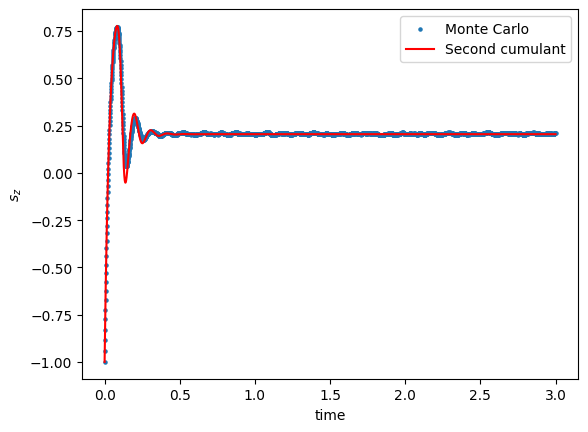

PyObject <matplotlib.legend.Legend object at 0x33d0246e0>

In [ ]:
w = 30.0
pars = BadCavityParams(
    N = 10^3,
    g = 37.0,
    kappa = 9.4e3,
    gamma = 0.0,
    w = w,
    gamma_phi = 0.0,
    Delta = 0.0
)

tmax = 3.0
u0 = [-1.0, 0.0, 0.0, 0.0, 0.0]
prob = ODEProblem(badcavity_rhs!, u0, (0.0, tmax), pars, dt =  1e-3)
sol = solve(prob, Tsit5())

mc_model = PopulationModel(
    pars.N,
    pars.N ÷ 2,
    pars.g ^ 2 / pars.kappa,
    0.0,
    0.0,
    pars.w,
    0.0,
)

obs_M(S, M, model) = M

t_grid, avg_M_mc = simulate_population_ensemble(
        mc_model,
        obs_M,
        200;
        S0 = mc_model.Jmax,
        M0 = -mc_model.Jmax,
        t_max = tmax,
        n_grid = 3000,
        rng = Xoshiro(1234),
)

scatter(t_grid, avg_M_mc / pars.N * 2, label = "Monte Carlo", s = 5)
plot(sol.t, map(x->x[1], sol.u), label = "Second cumulant", color = "red")
xlabel("time")
ylabel(L"s_z")
legend()

In [ ]:
τ_grid, Cτ_qs_mc, S_samples, M_samples, stats = simulate_correlator_ergodic_qs(
    mc_model;
    N_traj = 2000,
    t_ss = tmax,
    τ_max = 10000.0,
    t_mix = tmax,
    n_grid = 3000,
    tail_mode = :deterministic,
    rng = Xoshiro(1234),
)

ss, Sω = steady_state_and_spectrum(ωgrid, pars; tmax = tmax)
mc_ω_grid, mc_Sω = spectrum_even_fft(τ_grid, Cτ_qs_mc)
plot(mc_ω_grid / (2.0 * pi), mc_Sω / maximum(mc_Sω), label = "qs")


ωgrid = range(-0.15, 0.15, length=5001)
plot(ωgrid, Sω / maximum(abs.(Sω)), label = "mean field")
xlim(left = -0.03, right = 0.03)
legend()

LoadError: UndefVarError: `ωgrid` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

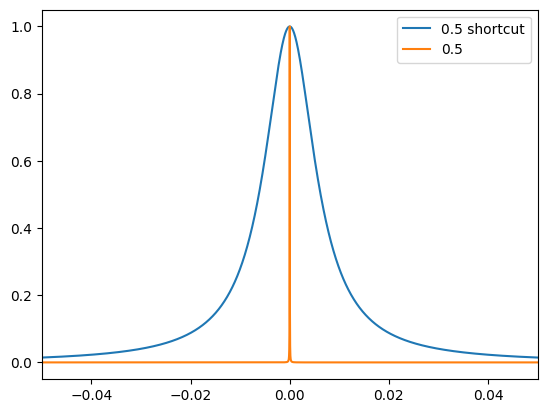

PyObject <matplotlib.legend.Legend object at 0x374063620>

In [ ]:
N = 1000
scale = 0.05

for r_fac in [0.5]

    mc_model = PopulationModel(N, N ÷ 2, 1.0 * scale, 0.0, 0.0, r_fac * N * scale, 0.0)

    τ_grid, Cτ_qs_mc, S_samples, M_samples, stats = simulate_correlator_ergodic_qs(
        mc_model;
        N_traj = 5000,
        t_ss = 0.05 / scale,
        τ_max = 400.0 / scale,
        t_mix = 0.05 / scale,
        n_grid = 5000,
        tail_mode = :deterministic,
        rng = Xoshiro(1234),
    )

    figure()
    mc_ω_grid, mc_Sω = spectrum_even_fft(τ_grid, Cτ_qs_mc)
    plot(mc_ω_grid / (2.0 * pi), mc_Sω / maximum(mc_Sω), label = "$r_fac shortcut")


    pars = BadCavityParams(
        N = mc_model.N,
        g = 1.0 * sqrt(scale),
        kappa = 1.0,
        gamma = 0.0,
        w = r_fac * N * scale,
        gamma_phi = 0.0,
        Delta = 0.0
    )


    ωgrid = range(-1.0 * scale, 1.0 * scale, length=10000)
    ss, Sω = steady_state_and_spectrum(ωgrid, pars; tmax=1000.0)
    plot(ωgrid, Sω / maximum(abs.(Sω)), label = r_fac)

    xlim(left = -1.0 * scale, right = 1.0 * scale)
end
legend()

In [ ]:
using QuantumOptics
using PyPlot
using LinearAlgebra
using OrdinaryDiffEq

# ------------------------------------------------------------
# Full positive-time spectrum:
# S(ω) = 2 Re ∫_0^∞ dτ e^{-iωτ} C(τ)
# Works for real or complex C(τ)
# ------------------------------------------------------------
function spectrum_from_positive_time_correlator(τ_grid, Cτ, ω_grid; η=0.0)
    Δτ = τ_grid[2] - τ_grid[1]
    damp = exp.(-η .* τ_grid)
    Sω = zeros(Float64, length(ω_grid))

    @inbounds for (i, ω) in pairs(ω_grid)
        Sω[i] = 2 * real(sum(Cτ .* damp .* exp.(-1im * ω .* τ_grid)) * Δτ)
    end

    return Sω
end

# ------------------------------------------------------------
# Build exact cavity + N local spins in QuantumOptics.jl
# N_exact should be small (e.g. 4, 6, maybe 8)
# ------------------------------------------------------------
function build_exact_cavity_spin_ops(N_exact; ncav=4)
    b_cav = FockBasis(ncav)
    b_atom = SpinBasis(1//2)
    b_spin = tensor([b_atom for _ in 1:N_exact]...)

    I_cav = identityoperator(b_cav)
    I_spin = identityoperator(b_spin)

    a_cav = destroy(b_cav)
    a = tensor(a_cav, I_spin)
    ad = dagger(a)
    n = ad * a

    sm_loc_spin = [embed(b_spin, i, sigmam(b_atom)) for i in 1:N_exact]
    sp_loc_spin = [embed(b_spin, i, sigmap(b_atom)) for i in 1:N_exact]
    sz_loc_spin = [embed(b_spin, i, sigmaz(b_atom)) for i in 1:N_exact]

    sm_loc = [tensor(I_cav, op) for op in sm_loc_spin]
    sp_loc = [tensor(I_cav, op) for op in sp_loc_spin]
    sz_loc = [tensor(I_cav, op) for op in sz_loc_spin]

    Sminus = reduce(+, sm_loc)
    Splus  = reduce(+, sp_loc)
    Sz     = 0.5 * reduce(+, sz_loc)

    return (
        b_cav = b_cav,
        b_spin = b_spin,
        a = a,
        ad = ad,
        n = n,
        sm_loc = sm_loc,
        sp_loc = sp_loc,
        sz_loc = sz_loc,
        Sminus = Sminus,
        Splus = Splus,
        Sz = Sz,
    )
end

# ------------------------------------------------------------
# Exact cavity spectrum from QuantumOptics.jl + regression
#
# Convention used here:
#   H = Δ a†a + g(a† S^- + a S^+)
#
# If your badcavity_rhs! uses the opposite sign for Δ,
# flip that one line below.
# ------------------------------------------------------------
function exact_cavity_spin_spectrum_qo(
    pars;
    N_exact::Int = 6,
    ncav::Int = 4,
    τ_max::Float64 = 400.0,
    nτ::Int = 6001,
    ωgrid = collect(range(-10.0, 10.0, length=4001)),
)
    ops = build_exact_cavity_spin_ops(N_exact; ncav=ncav)

    H = pars.Delta * ops.n + pars.g * (ops.ad * ops.Sminus + ops.a * ops.Splus)

    J = Any[]
    push!(J, sqrt(pars.kappa) * ops.a)

    if pars.gamma > 0
        for op in ops.sm_loc
            push!(J, sqrt(pars.gamma) * op)
        end
    end

    if pars.w > 0
        for op in ops.sp_loc
            push!(J, sqrt(pars.w) * op)
        end
    end

    # This matches L_deph[ρ] = (gamma_phi/2) * (σz ρ σz - ρ)
    if pars.gamma_phi > 0
        for op in ops.sz_loc
            push!(J, sqrt(pars.gamma_phi / 2) * op)
        end
    end

    ρss = try
        steadystate.eigenvector(H, J; which=:SM)
    catch
        steadystate.eigenvector(H, J)
    end

    τ_grid = collect(range(0.0, τ_max, length=nτ))
    Cτ = timecorrelations.correlation(τ_grid, ρss, H, J, ops.ad, ops.a)
    Sω = spectrum_from_positive_time_correlator(τ_grid, Cτ, ωgrid)

    nbar = real(expect(ops.n, ρss))

    return (
        τ_grid = τ_grid,
        Cτ = Cτ,
        ωgrid = collect(ωgrid),
        Sω = Sω,
        ρss = ρss,
        nbar = nbar,
    )
end

# ------------------------------------------------------------
# Your eliminated PI model, using YOUR convention Γeff = g^2/κ
# ------------------------------------------------------------
function population_model_from_badcavity(pars, N_exact::Int)
    return PopulationModel(
        N_exact,
        N_exact ÷ 2,
        4 * pars.g^2 / pars.kappa,  # your convention
        0.0,
        pars.gamma,
        pars.w,
        pars.gamma_phi,
    )
end

function deterministic_eliminated_correlator(
    pars;
    N_exact::Int = 6,
    τ_max::Float64 = 400.0,
    nτ::Int = 6001,
)
    model = population_model_from_badcavity(pars, N_exact)

    params = Dict(
        "global_decay"     => model.global_decay,
        "global_pump"      => model.global_pump,
        "local_decay"      => model.local_decay,
        "local_pump"       => model.local_pump,
        "local_dephasing"  => model.local_dephasing,
    )

    pop_basis, _, Rpop, _ = set_up_rate_matrix(model.Jmax, params)
    pss = steady_state_from_rate_matrix(Rpop)

    coh_basis, coh_index, Rcoh, _ = set_up_coherence_rate_matrix(model.Jmax, params)
    c0 = coherence_initial_from_population_ss(pop_basis, pss, coh_index)
    readout = coherence_readout_vector(coh_basis)

    function rhs!(dc, c, p, t)
        mul!(dc, Rcoh, c)
        return nothing
    end

    τ_grid = collect(range(0.0, τ_max, length=nτ))
    prob = ODEProblem(rhs!, c0, (0.0, τ_max))
    sol = solve(prob, Tsit5(); saveat=τ_grid, reltol=1e-9, abstol=1e-9)

    Cτ = ComplexF64[dot(readout, u) for u in sol.u]

    return (
        τ_grid = τ_grid,
        Cτ = Cτ,
        pop_ss = pss,
        model = model,
    )
end

# ------------------------------------------------------------
# Wrapper for your existing bad-cavity cavity-spectrum code
# Assumes BadCavityParams and steady_state_and_spectrum already exist.
# ------------------------------------------------------------
function badcavity_cumulant_spectrum(
    pars;
    N_exact::Int = 6,
    ωgrid = collect(range(-10.0, 10.0, length=4001)),
    tmax_ss::Float64 = 20.0,
)
    pars_small = BadCavityParams(
        N = N_exact,
        g = pars.g,
        kappa = pars.kappa,
        gamma = pars.gamma,
        w = pars.w,
        gamma_phi = pars.gamma_phi,
        Delta = pars.Delta,
    )

    ss, Sω = steady_state_and_spectrum(ωgrid, pars_small; tmax=tmax_ss)

    return (
        ωgrid = collect(ωgrid),
        Sω = Sω,
        ss = ss,
        pars = pars_small,
    )
end

# ------------------------------------------------------------
# Main comparison
# ------------------------------------------------------------
function compare_three_spectra(
    pars;
    N_exact::Int = 6,          # keep small; your PI code also wants even N
    ncav::Int = 4,             # cavity cutoff
    τ_max::Float64 = 400.0,
    nτ::Int = 6001,
    ωmax::Float64 = 8.0,
    nω::Int = 4001,
    tmax_bad::Float64 = 20.0,
    η::Float64 = 0.0,
    xlim_hz = nothing,
)
    @assert iseven(N_exact) "Use even N_exact so that your PopulationModel convention Jmax = N ÷ 2 matches exactly."

    ωgrid = collect(range(-ωmax, ωmax, length=nω))

    # same small-N parameters for all three curves
    pars_small = BadCavityParams(
        N = N_exact,
        g = pars.g,
        kappa = pars.kappa,
        gamma = pars.gamma,
        w = pars.w,
        gamma_phi = pars.gamma_phi,
        Delta = pars.Delta,
    )

    exact = exact_cavity_spin_spectrum_qo(
        pars_small;
        N_exact = N_exact,
        ncav = ncav,
        τ_max = τ_max,
        nτ = nτ,
        ωgrid = ωgrid,
    )

    elim = deterministic_eliminated_correlator(
        pars_small;
        N_exact = N_exact,
        τ_max = τ_max,
        nτ = nτ,
    )
    Sω_elim = spectrum_from_positive_time_correlator(elim.τ_grid, elim.Cτ, ωgrid; η=η)

    bad = badcavity_cumulant_spectrum(
        pars_small;
        N_exact = N_exact,
        ωgrid = ωgrid,
        tmax_ss = tmax_bad,
    )

    # normalized comparison
    y_exact = exact.Sω ./ maximum(abs.(exact.Sω))
    y_elim  = Sω_elim   ./ maximum(abs.(Sω_elim))
    y_bad   = bad.Sω    ./ maximum(abs.(bad.Sω))

    figure(figsize=(7.0, 4.5))
    plot(ωgrid ./ (2π), y_exact, label="exact cavity+spin (QuantumOptics)")
    plot(ωgrid ./ (2π), y_elim, "--", label="eliminated deterministic")
    plot(ωgrid ./ (2π), y_bad, ":", label="bad-cavity cumulant")

    xlabel(L"(\omega-\omega_0)/(2\pi)")
    ylabel("normalized spectrum")
    title("Three-way spectrum comparison")
    grid(true)
    legend()

    if xlim_hz !== nothing
        xlim(-xlim_hz, xlim_hz)
    end

    tight_layout()
    display(gcf())

    println("Exact small-N cavity photon number = ", exact.nbar)
    println("Chosen cavity cutoff ncav = ", ncav)
    println("Rule of thumb: want nbar << ncav so truncation is harmless.")

    return (
        ωgrid = ωgrid,
        exact = exact,
        eliminated = merge(elim, (Sω = Sω_elim,)),
        badcavity = bad,
    )
end

pars = BadCavityParams(
    N = 4,
    g = 1.0,
    kappa = 10.0,
    gamma = 0.0,
    w = 0.3,
    gamma_phi = 0.0,
    Delta = 0.0,
)

compare_three_spectra(pars; N_exact = pars.N, ncav = 2, τ_max = 20.0)

compare_three_spectra (generic function with 1 method)

In [ ]:
pars = BadCavityParams(
    N = 4,
    g = 1.0,
    kappa = 10.0,
    gamma = 0.0,
    w = 0.3,
    gamma_phi = 0.0,
    Delta = 0.0,
)

println(pars.w / (pars.N * pars.g^2/pars.kappa))


    N_exact = pars.N
    ncav = 2
    τ_max = 20.0
    nτ = 6001
    ωgrid = collect(range(-10.0, 10.0, length=4001))
    ops = build_exact_cavity_spin_ops(N_exact; ncav=ncav)

    H = pars.Delta * ops.n + pars.g * (ops.ad * ops.Sminus + ops.a * ops.Splus)

    J = Any[]
    push!(J, sqrt(pars.kappa) * ops.a)

    if pars.gamma > 0
        for op in ops.sm_loc
            push!(J, sqrt(pars.gamma) * op)
        end
    end

    if pars.w > 0
        for op in ops.sp_loc
            push!(J, sqrt(pars.w) * op)
        end
    end

    # This matches L_deph[ρ] = (gamma_phi/2) * (σz ρ σz - ρ)
    if pars.gamma_phi > 0
        for op in ops.sz_loc
            push!(J, sqrt(pars.gamma_phi / 2) * op)
        end
    end

    ρss = try
        steadystate.eigenvector(H, J; which=:SM)
    catch
        steadystate.eigenvector(H, J)
    end

    τ_grid = collect(range(0.0, τ_max, length=nτ))
    Cτ = timecorrelations.correlation(τ_grid, ρss, H, J, ops.ad, ops.a)
    Sω = spectrum_from_positive_time_correlator(τ_grid, Cτ, ωgrid)

    nbar = real(expect(ops.n, ρss))


0.7499999999999999


0.06268591689902746

In [ ]:
elim = deterministic_eliminated_correlator(
        pars;
        N_exact = N_exact,
        τ_max = τ_max * 5,
        nτ = nτ,
    )
    Sω_elim = spectrum_from_positive_time_correlator(elim.τ_grid, elim.Cτ, ωgrid)
bad = badcavity_cumulant_spectrum(
        pars;
        N_exact = N_exact,
        ωgrid = ωgrid,
        tmax_ss = 52000.0,
    )

(ωgrid = [-10.0, -9.995, -9.99, -9.985, -9.98, -9.975, -9.97, -9.965, -9.96, -9.955  …  9.955, 9.96, 9.965, 9.97, 9.975, 9.98, 9.985, 9.99, 9.995, 10.0], Sω = [1.331107598137593e-5, 1.3335002481732437e-5, 1.335898181667114e-5, 1.3383014123980689e-5, 1.3407099541869541e-5, 1.343123820895728e-5, 1.3455430264280692e-5, 1.3479675847292028e-5, 1.3503975097865946e-5, 1.3528328156295604e-5  …  1.3528328156295604e-5, 1.3503975097865946e-5, 1.3479675847292028e-5, 1.3455430264280692e-5, 1.343123820895728e-5, 1.3407099541869541e-5, 1.3383014123980689e-5, 1.335898181667114e-5, 1.3335002481732437e-5, 1.331107598137593e-5], ss = (z = 0.33985694203533795, p = 0.0 + 0.09902145869469932im, c = 0.11217710049286347, n = 0.03960858347787973, sol = ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, BadCavityParams, ODEFunction{true, SciMLBase.AutoSpecialize, FunctionWrappers

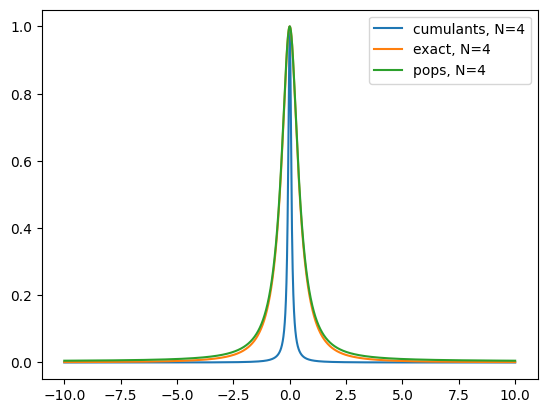

PyObject <matplotlib.legend.Legend object at 0x33eb56ba0>

In [ ]:
plot(bad.ωgrid, bad.Sω / maximum(abs.(bad.Sω )), label = "cumulants, N=$(pars.N)")
plot(ωgrid, Sω / maximum(Sω), label = "exact, N=$(pars.N)")
plot(ωgrid, Sω_elim / maximum(Sω_elim), label = "pops, N=$(pars.N)")

legend()

pars.w / ((pars.g ^ 2 / pars.kappa) * N) = 0.3
pars.w / ((pars.g ^ 2 / pars.kappa) * N) = 0.6
pars.w / ((pars.g ^ 2 / pars.kappa) * N) = 1.2


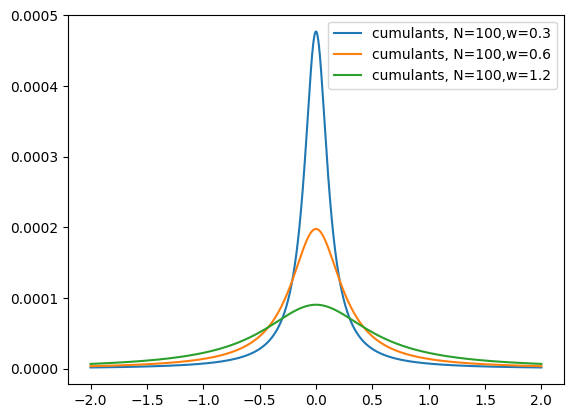

PyObject <matplotlib.legend.Legend object at 0x36c54c050>

In [ ]:
ωgrid = collect(range(-2.0, 2.0, length=4001))

for w in [0.3, 0.6, 1.2]

    pars = BadCavityParams(
        N = 100,
        g = 1.0,
        kappa = 1.0 * N,
        gamma = 0.0,
        w = w,
        gamma_phi = 0.0,
        Delta = 0.0,
    )

    @show pars.w / (pars.g^2 / pars.kappa * N)

    #elim = deterministic_eliminated_correlator(
    #        pars;
    #        N_exact = pars.N,
    #        τ_max = τ_max * 5,
    #        nτ = nτ * 2,
    #    )
    #Sω_elim = spectrum_from_positive_time_correlator(elim.τ_grid, elim.Cτ, ωgrid)
    bad = badcavity_cumulant_spectrum(
            pars;
            N_exact = pars.N,
            ωgrid = ωgrid,
            tmax_ss = 520.0,
        )


    #figure()
    plot(bad.ωgrid, bad.Sω, label = "cumulants, N=$(pars.N),w=$w")
    #plot(ωgrid, Sω_elim, label = "pops, N=$(pars.N),w=$w")
end

legend()


In [ ]:
using PyPlot

function linewidth_from_regression_matrix(pars, ss)
    A = regression_matrix(pars, ss.z)
    vals = eigvals(A)
    λslow = vals[argmax(real.(vals))]
    Δω = -2 * real(λslow)
    Δν = Δω / (2π)
    return Δν
end

# --------------------------------
# linewidth scan for PRL Fig. 3(b)
# --------------------------------
function scan_w_linewidth_badcavity(
    ws;
    N::Int = 10^6,
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # use this as 1/T2
    Delta::Float64 = 0.0,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    widths = Float64[]
    nss = Float64[]
    zss = Float64[]
    pss = ComplexF64[]

    for w in ws
        #@show w
        pars = BadCavityParams(
            N = N,
            g = g,
            kappa = kappa,
            gamma = gamma,
            w = w,
            gamma_phi = gamma_phi,
            Delta = Delta,
        )

        # choose a frequency window that scales with the expected broadening
        # at large w the linewidth can become O(w), so use max(gamma_phi, w)
        ωmax = ωmax_factor * max(gamma_phi, gamma, w, g^2 * N / kappa / 100)
        #ωgrid = range(-ωmax, ωmax, length=nω)

        ss, Sω = steady_state_and_spectrum(ωgrid, pars; u0=u0, tmax=tmax_ss)
        #Δν = spectrum_fwhm(collect(ωgrid), Sω)
        push!(widths, linewidth_from_regression_matrix(pars, ss))

        #push!(widths, Δν)
        push!(nss, ss.n)
        push!(zss, ss.z)
        push!(pss, ss.p)
    end

    return (
        ws = collect(ws),
        widths = widths,
        nss = nss,
        zss = zss,
        pss = pss,
        wmax = N * g^2 / kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
    )
end

# --------------------------------
# plotting helper for panel (b)
# --------------------------------
function plot_prl_fig3b_like(scan)
    figure(figsize=(5.2, 4.0))

    loglog(scan.ws, scan.widths, label = L"\Delta \nu")

    axvline(scan.gamma, color="k", linestyle="--", linewidth=1)
    axvline(scan.gamma_phi, color="k", linestyle="--", linewidth=1)
    axvline(scan.wmax, color="k", linestyle="--", linewidth=1)

    xlabel(L"w\ [\mathrm{s}^{-1}]")
    ylabel(L"\Delta \nu\ [\mathrm{s}^{-1}]")

    text(scan.gamma * 1.05, maximum(scan.widths) / 5, L"\gamma")
    text(scan.gamma_phi * 1.05, maximum(scan.widths) / 5, L"T_2^{-1}")
    text(scan.wmax * 1.05, maximum(scan.widths) / 5, L"w_{\max}")

    grid(true, which="both", alpha=0.3)
    tight_layout()
end

# --------------------------------
# reasonable defaults for arbitrary N
# reuses:
#   scan_w_linewidth_badcavity
#   plot_prl_fig3b_like
# --------------------------------
function plot_linewidth_cut_for_N(
    N::Int;
    g::Float64 = 37.0,
    kappa::Float64 = 9.4e5,
    gamma::Float64 = 0.01,
    gamma_phi::Float64 = 1.0,   # interpreted as 1/T2 in your code
    Delta::Float64 = 0.0,
    ws = nothing,
    npts::Int = 120,
    nω::Int = 12001,
    ωmax_factor::Float64 = 20.0,
    tmax_ss::Float64 = 2.0e4,
    u0 = [0.0, 0.0, 0.0, 0.0, 0.0],
)
    wmax = N * g^2 / kappa

    if ws === nothing
        scales = [gamma, gamma_phi, wmax]
        positive_scales = [x for x in scales if x > 0]
        wmin = min(minimum(positive_scales) / 10, 1e-3)
        wmax_plot = max(maximum(positive_scales) * 100, 1e2)
        ws = 10.0 .^ range(log10(wmin), log10(wmax_plot), length=npts)
    end

    @show g^2 / kappa

    scan = scan_w_linewidth_badcavity(
        ws;
        N = N,
        g = g,
        kappa = kappa,
        gamma = gamma,
        gamma_phi = gamma_phi,
        Delta = Delta,
        nω = nω,
        ωmax_factor = ωmax_factor,
        tmax_ss = tmax_ss,
        u0 = u0,
    )

    plot_prl_fig3b_like(scan)
    title("N = $(N)")

    return scan
end

plot_linewidth_cut_for_N (generic function with 1 method)

In [ ]:
using PyPlot
using Random
using LsqFit

function linewidth_from_correlator_tail(τ_grid, Cτ; fit_frac=(0.2, 0.8))
    a, b = fit_frac
    N = length(τ_grid)
    i1 = max(2, round(Int, a * N))
    i2 = min(N, round(Int, b * N))

    τ = τ_grid[i1:i2]
    y = abs.(real.(Cτ[i1:i2]))

    mask = y .> 0
    τ = τ[mask]
    y = y[mask]

    if length(τ) < 5
        return NaN
    end

    X = hcat(ones(length(τ)), τ)
    β = X \ log.(y)
    slope = β[2]

    Δω = -2 * slope
    return Δω / (2π)
end

# --------------------------------
# MC linewidth scan vs w
# Reuses:
#   PopulationModel
#   simulate_correlator_ergodic_qs
#   spectrum_even_fft
#   spectrum_fwhm
# --------------------------------
function scan_w_linewidth_mc(
    ws;
    N::Int,
    global_decay::Float64,
    local_decay::Float64 = 0.0,
    local_dephasing::Float64 = 0.0,
    N_traj::Int = 2000,
    t_ss = nothing,
    t_mix = nothing,
    τ_max = nothing,
    n_grid::Int = 4000,
    tail_mode = :deterministic,
    seed::Int = 1234,
    verbose::Bool = true,
)
    # sensible defaults in units of the effective collective rate scale
    Γcoll = N * global_decay
    t_ss === nothing && (t_ss = 20 / Γcoll)
    t_mix === nothing && (t_mix = t_ss)
    τ_max === nothing && (τ_max = 200 / global_decay)

    widths = Float64[]
    spectra = Vector{Vector{Float64}}()
    ωgrids = Vector{Vector{Float64}}()

    for (j, w) in pairs(ws)
        verbose && println("[$j/$(length(ws))] w = $w")

        mc_model = PopulationModel(
            N,
            N ÷ 2,
            global_decay,
            0.0,
            local_decay,
            w,
            local_dephasing,
        )

        τ_grid, Cτ_qs_mc, S_samples, M_samples, stats = simulate_correlator_ergodic_qs(
            mc_model;
            N_traj = N_traj,
            t_ss = t_ss,
            τ_max = τ_max,
            t_mix = t_mix,
            n_grid = n_grid,
            tail_mode = tail_mode,
            rng = Xoshiro(seed),
        )


        Δν = linewidth_from_correlator_tail(τ_grid, Cτ_qs_mc)
        plot(τ_grid, Cτ_qs_mc)

        push!(widths, Δν)
        push!(ωgrids, ω_grid)
    end

    return (
        ws = collect(ws),
        widths = widths,
        ωgrids = ωgrids,
        spectra = spectra,
        global_decay = global_decay,
        N = N,
        local_decay = local_decay,
        local_dephasing = local_dephasing,
        t_ss = t_ss,
        t_mix = t_mix,
        τ_max = τ_max,
        N_traj = N_traj,
    )
end

# --------------------------------
# Plot helper in the same spirit as the PRL-style cut
# --------------------------------
function plot_linewidth_scan_mc(scan; gamma=nothing, gamma_phi=nothing, show_wmax=true)
    figure(figsize=(5.4, 4.0))
    loglog(scan.ws, scan.widths, marker="o", linestyle="-", label="MC")

    if gamma !== nothing && gamma > 0
        axvline(gamma, color="k", linestyle="--", linewidth=1)
    end
    if gamma_phi !== nothing && gamma_phi > 0
        axvline(gamma_phi, color="k", linestyle="--", linewidth=1)
    end
    if show_wmax
        wmax = scan.N * scan.global_decay
        axvline(wmax, color="k", linestyle="--", linewidth=1)
    end

    xlabel(L"w")
    ylabel(L"\Delta \nu")
    grid(true, which="both", alpha=0.3)
    legend()
    tight_layout()
end

g ^ 2 / kappa = 0.0014563829787234042


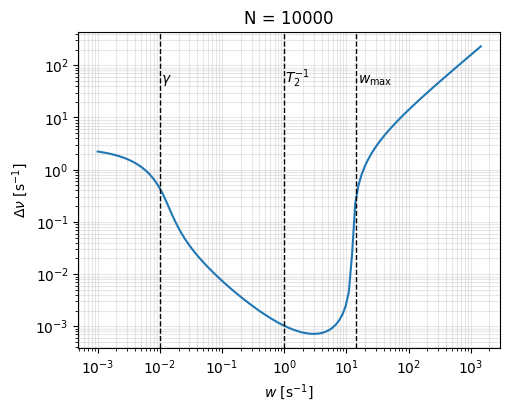

(ws = [0.001, 0.0011266583296444012, 0.0012693589917571108, 0.0014301338813721676, 0.0016112722499546305, 0.0018153533017362601, 0.0020452829186486214, 0.002304335036774881, 0.0025961982634738574, 0.0029250283989511513  …  497.90387650445706, 560.9675498259838, 632.0187626716553, 712.0692034555684, 802.258699356469, 903.8714461596493, 1018.3542937434997, 1147.3373475752553, 1292.6571795577734, 1456.3829787234038], widths = [2.2244360907485508, 2.177464446876026, 2.1258340013294914, 2.069241652331175, 2.007401747856066, 1.9400564257638284, 1.866987564024006, 1.7880302696910118, 1.7030877627091836, 1.6121474604374086  …  77.2447687784679, 87.28149636462771, 98.58946197336667, 111.32967815375228, 125.68355107117675, 141.8554635238634, 160.0756851203209, 180.60365105530556, 203.73165617025504, 229.78901689732712], nss = [1.9888994534132364e-7, 2.2628079715278157e-7, 2.5778897625058615e-7, 2.941368161833986e-7, 3.3620516850969007e-7, 3.850782325719082e-7, 4.4210443758089395e-7, 5.0898043116

In [ ]:
plot_linewidth_cut_for_N(10^4)

In [ ]:
using Profile
using ProfileView

In [ ]:
N = 10000
g = 37.0
kappa = 9.4e5
gamma = 0.01
gamma_phi = 1.0
Delta = 0.0

Γ = 4 * g^2 / kappa
ws = 10.0 .^ range(-3, 4, length=50) .* (N * Γ)

scan_cum = scan_w_linewidth_badcavity(
    ws;
    N = N,
    g = g,
    kappa = kappa,
    gamma = gamma,
    gamma_phi = gamma_phi,
    Delta = Delta,
    tmax_ss = 2.0e4,
)



scan_mc = @profile scan_w_linewidth_mc(
    ws[1:2];
    N = N,
    global_decay = Γ,
    local_decay = gamma,
    local_dephasing = gamma_phi,
    N_traj = 3000,
    t_ss = 0.05 / Γ,
    t_mix = 0.05 / Γ,
    τ_max = 200.0 / Γ,
    n_grid = 5000,
    tail_mode = :deterministic,
    seed = 1234,
    verbose = true
)

: 

In [ ]:
ProfileView.view()

Gtk4.GtkWindowLeaf(accessible-role=GTK_ACCESSIBLE_ROLE_WINDOW, name="", parent, root, width-request=-1, height-request=-1, visible=true, sensitive=true, can-focus=true, has-focus=false, can-target=true, focus-on-click=true, focusable=false, has-default=false, receives-default=false, cursor, has-tooltip=false, tooltip-markup=nothing, tooltip-text=nothing, opacity=1.000000, overflow=GTK_OVERFLOW_HIDDEN, halign=GTK_ALIGN_FILL, valign=GTK_ALIGN_FILL, margin-start=0, margin-end=0, margin-top=0, margin-bottom=0, hexpand=false, vexpand=false, hexpand-set=false, vexpand-set=false, scale-factor=2, css-name="window", css-classes, layout-manager, limit-events=false, title="Profile", resizable=true, modal=false, default-width=800, default-height=600, destroy-with-parent=false, hide-on-close=false, icon-name=nothing, display, decorated=true, deletable=true, transient-for, application, default-widget, focus-widget, child, titlebar, handle-menubar-accel=true, is-active=false, suspended=false, startup

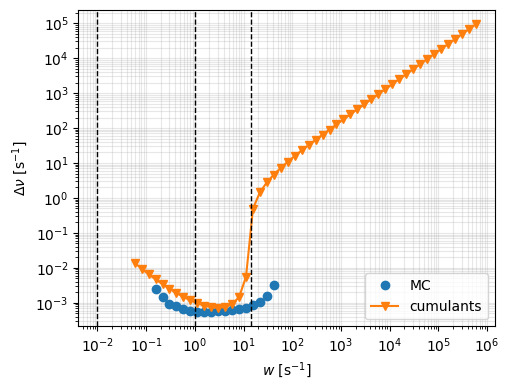

In [ ]:
figure(figsize=(5.2, 4.0))
loglog(scan_mc.ws, scan_mc.widths, marker="o", linestyle="none", label="MC")
loglog(scan_cum.ws, scan_cum.widths, marker="v", label="cumulants")

axvline(scan_cum.gamma, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.gamma_phi, color="k", linestyle="--", linewidth=1)
axvline(scan_cum.wmax, color="k", linestyle="--", linewidth=1)

xlabel(L"w\ [\mathrm{s}^{-1}]")
ylabel(L"\Delta \nu\ [\mathrm{s}^{-1}]")
grid(true, which="both", alpha=0.3)
legend()
tight_layout()